In [19]:
%pip install -r ../requirements.txt


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Set up database

In [20]:
from dotenv import load_dotenv
import os
from IPython.display import display

load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
dbname = os.getenv("DB_NAME")

from sqlalchemy import create_engine
engine = create_engine(f"mysql+mysqlconnector://{user}:{password}@{host}/{dbname}", connect_args={'init_command': 'SET time_zone="+07:00"'})

# Sleep

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

,SLEEP_START_CATEGORY,SLEEP_END_CATEGORY,WAKE_FEELING_CATEGORY,MINUTES_PER_DAY_CATEGORY,count
0,Early,Early,Good,Acceptable,2
1,Early,Early,Good,None,3
2,Early,Late,Good,Acceptable,3
3,Early,Late,Good,Good,2
4,Early,Late,Good,None,1
5,Late,Early,Bad,Acceptable,3
6,Late,Early,Bad,Good,2
7,Late,Early,Bad,None,5
8,Late,Early,Good,Acceptable,4
9,Late,Early,Good,Good,5


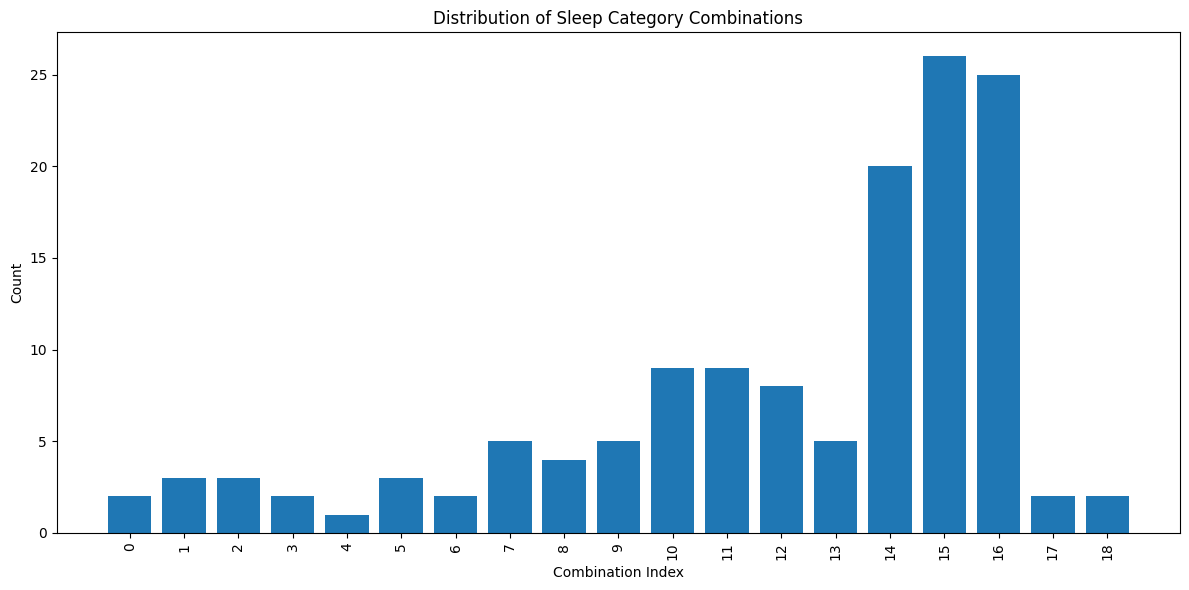

In [22]:
query = "SELECT * FROM ML_FOR_SLEEP"
df = pd.read_sql(query, engine)

combo_counts = df.groupby(
    [
        "SLEEP_START_CATEGORY",
        "SLEEP_END_CATEGORY",
        "WAKE_FEELING_CATEGORY",
        "MINUTES_PER_DAY_CATEGORY"
    ]
).size().reset_index(name="count")

display(combo_counts)

combo_counts["label"] = combo_counts.index.astype(str)

plt.figure(figsize=(12, 6))
plt.bar(combo_counts["label"], combo_counts["count"])
plt.xlabel("Combination Index")
plt.ylabel("Count")
plt.title("Distribution of Sleep Category Combinations")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Sklearn

setting up

In [23]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

label_encoders = {}
for col in ["SLEEP_START_CATEGORY", "SLEEP_END_CATEGORY", "WAKE_FEELING_CATEGORY", "MINUTES_PER_DAY_CATEGORY"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

X = df[["SLEEP_START_CATEGORY", "SLEEP_END_CATEGORY", "WAKE_FEELING_CATEGORY"]]
y = df["MINUTES_PER_DAY_CATEGORY"]

clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=None,
    random_state=42
)
clf.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Decision tree

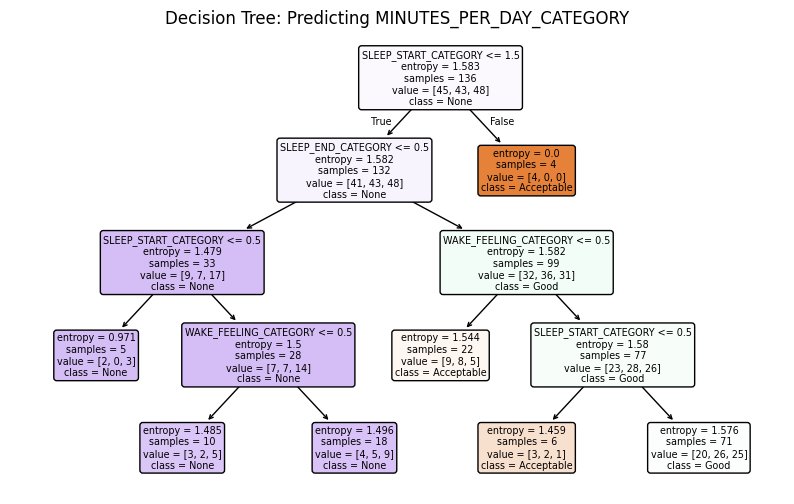

In [24]:
plt.figure(figsize=(10, 6))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=label_encoders["MINUTES_PER_DAY_CATEGORY"].classes_,
    filled=True,
    rounded=True
)
plt.title("Decision Tree: Predicting MINUTES_PER_DAY_CATEGORY")
plt.show()

Predict from new data

In [25]:
sample = pd.DataFrame([["Late", "Late", "Good"]], columns=X.columns)
for col in sample.columns:
    sample[col] = label_encoders[col].transform(sample[col])

pred = clf.predict(sample)
print(label_encoders["MINUTES_PER_DAY_CATEGORY"].inverse_transform(pred)[0])

Good


In [26]:
from package import ml

In [28]:
ml.sleep_via_study("Late", "Late", "Good")

'Good'